In [59]:
# ============================================================
# FINAL PROJECT — PREDICTIVE ANALYTICS IN BANKING
# PT Bank Sentral Merakyat (BSM) — Prediksi Deposito Berjangka
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from matplotlib.ticker import FuncFormatter

# Statistics
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display Config
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print("Libraries berhasil diimport")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version  : {np.__version__}")

Libraries berhasil diimport
Pandas version : 3.0.2
NumPy version  : 2.4.4


# PREDICTIVE ANALYTICS IN BANKING
## Prediksi Keberhasilan Kampanye Deposito Berjangka
### PT Bank Sentral Merakyat (BSM) — Divisi Data Science & Analytics

## A. BUSINESS UNDERSTANDING

### A.1 Background & Context

Pasca-pandemi COVID-19, PT Bank Sentral Merakyat (BSM) menghadapi tekanan ganda pada lini bisnis deposito berjangka.

Pada periode **2020–2021**, Bank Indonesia menurunkan suku bunga acuan (BI Rate) ke level terendah historis — 3,5% — untuk mendorong pemulihan ekonomi. Dampaknya: imbal hasil deposito tidak kompetitif dibandingkan instrumen lain seperti reksa dana pasar uang, Obligasi Ritel Indonesia (ORI), atau Sukuk Tabungan. Dana Pihak Ketiga (DPK) BSM pada segmen deposito berjangka mengalami stagnasi.

Memasuki **2022–2023**, Bank Indonesia memulai siklus pengetatan moneter secara agresif untuk meredam inflasi pasca-pandemi — BI Rate naik bertahap hingga menyentuh 6,0%. Kenaikan ini membuat deposito berjangka kembali menjadi instrumen investasi yang menarik bagi masyarakat.

BSM merespons peluang ini dengan meluncurkan **kampanye telemarketing** yang menargetkan:
1. Nasabah existing yang sebelumnya mengalihkan dana ke instrumen lain
2. Segmen prospek baru yang belum pernah berinvestasi di BSM

Tim Data Science BSM ditugaskan untuk membangun **model prediktif** yang mampu mengidentifikasi nasabah mana yang paling berpotensi menerima tawaran deposito berjangka — sehingga kampanye telemarketing dapat dijalankan lebih efisien dan tepat sasaran.

**Stakeholder utama:**
- **Chief Marketing Officer (CMO):** Butuh model untuk mengoptimalkan alokasi sumber daya call center
- **Tim Telemarketing:** Butuh daftar prioritas nasabah yang berpotensi tinggi
- **Tim Keuangan:** Butuh estimasi konversi untuk proyeksi DPK
- **Chief Risk Officer (CRO):** Butuh memastikan strategi tidak melanggar regulasi OJK terkait penjualan produk investasi

### A.2 Problem Statement

Berdasarkan konteks di atas, masalah yang dihadapi BSM dapat dirumuskan sebagai:

> **"Bagaimana memprediksi apakah seorang nasabah akan setuju membuka deposito berjangka di BSM melalui kampanye telemarketing, sehingga Tim Telemarketing dapat memprioritaskan kontak kepada nasabah dengan potensi konversi tertinggi?"**

Ini adalah masalah **klasifikasi biner**:
- **Kelas 1 (Subscribe = Yes):** Nasabah setuju membuka deposito berjangka
- **Kelas 0 (Subscribe = No):** Nasabah menolak tawaran

Tanpa model prediktif, Tim Telemarketing harus menghubungi semua nasabah secara acak — biaya tinggi, konversi rendah, dan banyak waktu agen yang terbuang.

### A.3 Cost of Errors — Mengapa FP dan FN Penting?

Dalam konteks kampanye telemarketing BSM, setiap kesalahan prediksi memiliki **dampak finansial yang asimetris**:

| Tipe | Prediksi | Realita | Skenario | Biaya |
|------|---------|---------|----------|-------|
| **True Positive (TP)** | Subscribe | Subscribe | Call relevan, nasabah berhasil dikonversi | Rp 50.000 (biaya 1 call) |
| **True Negative (TN)** | Tidak | Tidak | Nasabah tidak dihubungi, tidak ada biaya tambahan | Rp 0 |
| **False Positive (FP)** | Subscribe | Tidak | Call sia-sia, tidak ada konversi — waktu & biaya agen terbuang | Rp 50.000 |
| **False Negative (FN)** | Tidak | Subscribe | **Nasabah berharga terlewat, BSM kehilangan potensi margin deposito** | **Rp 500.000** |

#### Mengapa False Negative (FN) Jauh Lebih Fatal?

**Biaya per call (FP = Rp 50.000)** dihitung dari:
- Gaji telemarketer bank Indonesia: Rp 3.500.000–5.000.000/bulan
- Kapasitas: ~200 panggilan/bulan (10 call/hari × 20 hari kerja)
- Biaya gaji per call: Rp 17.500–25.000
- Ditambah overhead (VoIP, CRM, training, supervisor): ~100%
- **Total: ~Rp 35.000–50.000 per call** → digunakan Rp 50.000 (konservatif)

**Kehilangan per nasabah (FN = Rp 500.000)** dihitung dari:
- NIM (Net Interest Margin) rata-rata bank Indonesia: 4–5% per tahun (data OJK 2022)
- Rata-rata nominal deposito nasabah ritel BSM: ~Rp 50.000.000
- Gross spread: Rp 50 juta × 4% = Rp 2.000.000/tahun
- Setelah biaya operasional (~75% BOPO): **profit bersih ~Rp 500.000/nasabah/tahun**
- Belum termasuk: nilai cross-selling (KPR, kartu kredit), loyalitas jangka panjang

**Rasio biaya FN:FP = 10:1** → artinya setiap satu nasabah potensial yang terlewat setara kerugian 10 call sia-sia.

#### Kesimpulan: Minimasi False Negative adalah Prioritas Utama BSM.
Kita lebih baik *terlalu waspada* (menghubungi nasabah yang ternyata tidak mau) daripada *melewatkan* nasabah yang sebenarnya mau bergabung.

### A.4 Goals

**Goals Bisnis:**
1. Memprediksi nasabah yang berpotensi membuka deposito berjangka, sehingga Tim Telemarketing dapat fokus pada segmen berkonversi tinggi
2. Mengidentifikasi karakteristik demografis dan finansial "nasabah ideal" untuk deposito BSM
3. Mengoptimalkan biaya kampanye telemarketing dengan mengurangi call sia-sia (False Positive)
4. Memberikan rekomendasi strategis berbasis data: segmen mana yang diprioritaskan, timing terbaik, dan pendekatan yang efektif

**Goals Teknis:**
1. Membangun pipeline ML yang menghindari data leakage (stratified split, scaling dalam pipeline)
2. Menangani class imbalance (~89:11) dengan eksperimen resampling sistematis
3. Mengidentifikasi fitur-fitur dominan yang memengaruhi keputusan subscribe
4. Membangun model dengan F2-Score setinggi mungkin pada data test
5. Menentukan threshold optimal: F2-optimal (evaluasi model) dan Profit-optimal (deployment)
6. Menghitung simulasi ROI dalam Rupiah untuk memvalidasi nilai bisnis model

### A.5 Analytic Approach

Proyek ini menggunakan pendekatan **hybrid: Analytics + Machine Learning**:

**Analytics (Descriptive + Inferential):**
- Exploratory Data Analysis (EDA) mendalam dengan framework 5W-1H
- Uji signifikansi statistik formal (Chi-Square untuk kategorikal, T-test/ANOVA untuk numerikal)
- Segmentasi nasabah berbasis temuan EDA

**Machine Learning (Predictive):**
- Benchmarking sistematis: 6 algoritma × 5 strategi resampling = 30 kombinasi
- Hyperparameter tuning pada kombinasi terbaik
- Dual-threshold optimization: F2-optimal dan Profit-optimal (dalam Rupiah)

**Catatan penting — Duration Paradox:**
Kolom `duration` (durasi panggilan terakhir dalam detik) **mengandung data leakage**: nilainya hanya bisa diketahui *setelah* panggilan selesai, bukan *sebelum*. Oleh karena itu:
- `duration` **DIGUNAKAN** di bagian Analytics/EDA untuk mendapatkan insight
- `duration` **DIHAPUS** sebelum memasuki bagian Machine Learning

### A.6 Evaluation Metrics

**Metrik Utama: F2-Score**

$$F_2 = 5 \cdot \frac{\text{Precision} \times \text{Recall}}{4 \times \text{Precision} + \text{Recall}}$$

Dengan beta = 2, F2-Score memberikan **bobot 2× lebih besar pada Recall** dibandingkan Precision.

**Mengapa F2, bukan metrik lain?**

| Metrik | Masalah dalam Konteks BSM |
|--------|--------------------------|
| Accuracy | Misleading pada data imbalanced. Model yang selalu prediksi "tidak" punya akurasi 89% tapi tidak berguna |
| Recall murni | Recall 100% tercapai dengan prediksi "semua subscribe" → 41.000+ call sia-sia, ROI negatif |
| F1-Score | Bobot sama untuk FP dan FN, padahal FN 10× lebih mahal dari FP |
| **F2-Score** | Prioritaskan Recall (minimasi FN), tapi Precision tetap dijaga agar ROI positif |

**Metrik Pendukung:**

| Metrik | Fungsi |
|--------|--------|
| Recall | Berapa % nasabah yang mau terdeteksi — prioritas utama BSM |
| ROC-AUC | Kemampuan diskriminasi model secara keseluruhan |
| Precision | Monitoring agar call center tidak overload dengan false alarms |
| **Savings (Rp)** | **Metrik bisnis final: penghematan vs tanpa model** |
| ROI (%) | Return on Investment dari implementasi model |

## B. DATA UNDERSTANDING

### B.1 Import Libraries
*(Library sudah diimport pada cell pertama di atas)*

In [60]:
# ─────────────────────────────────────────────────────────────
# B.2 Load Dataset + Fix Macro Indicator Columns
# ─────────────────────────────────────────────────────────────

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("=" * 60)
print("DATASET BERHASIL DIMUAT")
print("=" * 60)
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
print(f"\n5 Baris Pertama:")
display(df.head())
print(f"\n5 Baris Terakhir:")
display(df.tail())

DATASET BERHASIL DIMUAT
Jumlah baris  : 41,188
Jumlah kolom  : 21

5 Baris Pertama:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no



5 Baris Terakhir:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no


In [61]:
# ─────────────────────────────────────────────────────────────
# FIX: Kolom Macro Indicator tersimpan sebagai object
# karena menggunakan koma sebagai pemisah desimal (format Eropa)
# Action : Ganti koma → titik, lalu konversi ke float
# Why    : Kolom-kolom ini adalah fitur numerik yang krusial
#          (JIBOR, IHK, IKK, dll). Jika dibiarkan sebagai object,
#          model tidak bisa membacanya sebagai angka.
# Business Impact: Macro indicators adalah konteks ekonomi yang
#          menjelaskan MENGAPA nasabah mau/tidak mau deposito.
# ─────────────────────────────────────────────────────────────

macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

print("Tipe data SEBELUM fix:")
print(df[macro_cols].dtypes.to_string())
print()

for col in macro_cols:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print("Tipe data SESUDAH fix:")
print(df[macro_cols].dtypes.to_string())
print()
print("Sample nilai setelah fix:")
display(df[macro_cols].head(3))

Tipe data SEBELUM fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Tipe data SESUDAH fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Sample nilai setelah fix:


,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed
0,1.1000,93.9940,-36.4000,"5,191.0000"
1,1.1000,93.9940,-36.4000,"5,191.0000"
2,1.1000,93.9940,-36.4000,"5,191.0000"


In [62]:
# ─────────────────────────────────────────────────────────────
# B.3 Dataset Overview — Info, Describe, Deskripsi Kolom
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("INFORMASI TIPE DATA & NON-NULL COUNT")
print("=" * 60)
df.info()

INFORMASI TIPE DATA & NON-NULL COUNT
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.

In [63]:
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF — FITUR NUMERIK")
print("=" * 60)
display(df.describe())


STATISTIK DESKRIPTIF — FITUR NUMERIK


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,"41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000"
mean,40.0241,258.2850,2.5676,962.4755,0.1730,0.0819,93.5757,-40.5026,3.6213,"5,167.0359"
std,10.4212,259.2792,2.7700,186.9109,0.4949,1.5710,0.5788,4.6282,1.7344,72.2515
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,"4,963.6000"
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,"5,099.1000"
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,"5,191.0000"
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,"5,228.1000"
max,98.0000,"4,918.0000",56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,"5,228.1000"


In [64]:
print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF — FITUR KATEGORIKAL")
print("=" * 60)
display(df.describe(include='object'))


STATISTIK DESKRIPTIF — FITUR KATEGORIKAL


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


#### Deskripsi Variabel Dataset

**Demografi & Profil Nasabah:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `age` | Numerik | Usia nasabah (tahun) |
| `job` | Kategorikal | Kategori pekerjaan (admin, blue-collar, entrepreneur, dll) |
| `marital` | Kategorikal | Status pernikahan (single, married, divorced) |
| `education` | Kategorikal | Tingkat pendidikan (ordinal: illiterate → university.degree) |
| `default` | Kategorikal | Riwayat kredit macet? (yes, no, unknown) |
| `housing` | Kategorikal | Punya pinjaman KPR? (yes, no, unknown) |
| `loan` | Kategorikal | Punya pinjaman pribadi? (yes, no, unknown) |

**Kampanye Saat Ini:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `contact` | Kategorikal | Jenis kontak (cellular / telephone) |
| `month` | Kategorikal | Bulan terakhir dihubungi |
| `day_of_week` | Kategorikal | Hari terakhir dihubungi |
| `duration` | Numerik | ⚠️ Durasi call terakhir (detik) — **HANYA untuk EDA, tidak masuk model** |
| `campaign` | Numerik | Jumlah kontak dalam kampanye ini |

**Riwayat Kampanye Sebelumnya:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `pdays` | Numerik | Hari sejak kontak kampanye sebelumnya (999 = belum pernah) |
| `previous` | Numerik | Jumlah kontak sebelum kampanye ini |
| `poutcome` | Kategorikal | Hasil kampanye sebelumnya (success, failure, nonexistent) |

**Macro Economic Indicators (Konteks BSM Indonesia):**
| Kolom | Tipe | Interpretasi untuk BSM |
|-------|------|----------------------|
| `emp.var.rate` | Numerik | Pertumbuhan Ketenagakerjaan YoY (Sakernas BPS) |
| `cons.price.idx` | Numerik | Indeks Harga Konsumen / IHK (BPS) |
| `cons.conf.idx` | Numerik | Indeks Keyakinan Konsumen / IKK (Survei BI) |
| `euribor3m` | Numerik | JIBOR 3 Bulan / Proksi BI Rate |
| `nr.employed` | Numerik | Jumlah Angkatan Kerja Aktif (juta orang, BPS) |

**Target Variable:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `y` | Kategorikal | Setuju membuka deposito berjangka? (yes / no) |

In [65]:
# ─────────────────────────────────────────────────────────────
# B.4 Missing Values Analysis
#
# PENTING: Dataset ini menggunakan string "unknown" sebagai
# representasi missing values — BUKAN NaN/null!
# df.isnull().sum() akan mengembalikan 0 untuk semua kolom
# padahal ada missing values yang tersembunyi.
#
# Langkah: Deteksi "unknown" terlebih dahulu sebelum
# menggantinya dengan NaN untuk analisis missingno.
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("CEK MISSING VALUES EKSPLISIT (NaN/null)")
print("=" * 60)
explicit_missing = df.isnull().sum()
if explicit_missing.sum() == 0:
    print("Tidak ada NaN/null eksplisit dalam dataset.")
    print(" TAPI perlu dicek: missing values mungkin direpresentasikan")
    print("    sebagai string 'unknown'!")
else:
    print(explicit_missing[explicit_missing > 0])

CEK MISSING VALUES EKSPLISIT (NaN/null)
Tidak ada NaN/null eksplisit dalam dataset.
 TAPI perlu dicek: missing values mungkin direpresentasikan
    sebagai string 'unknown'!


In [66]:
# Deteksi "unknown" per kolom
print("\n" + "=" * 60)
print("DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI")
print("=" * 60)

unknown_summary = []
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    pct_unknown = n_unknown / len(df) * 100
    if n_unknown > 0:
        unknown_summary.append({
            'Kolom': col,
            'Jumlah Unknown': n_unknown,
            'Persentase (%)': round(pct_unknown, 2)
        })

if unknown_summary:
    unknown_df = pd.DataFrame(unknown_summary).sort_values('Persentase (%)', ascending=False)
    print(unknown_df.to_string(index=False))
    print(f"\nTotal kolom dengan 'unknown': {len(unknown_df)}")
else:
    print("Tidak ada nilai 'unknown' ditemukan.")


DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI
    Kolom  Jumlah Unknown  Persentase (%)
  default            8597         20.8700
education            1731          4.2000
  housing             990          2.4000
     loan             990          2.4000
      job             330          0.8000
  marital              80          0.1900

Total kolom dengan 'unknown': 6


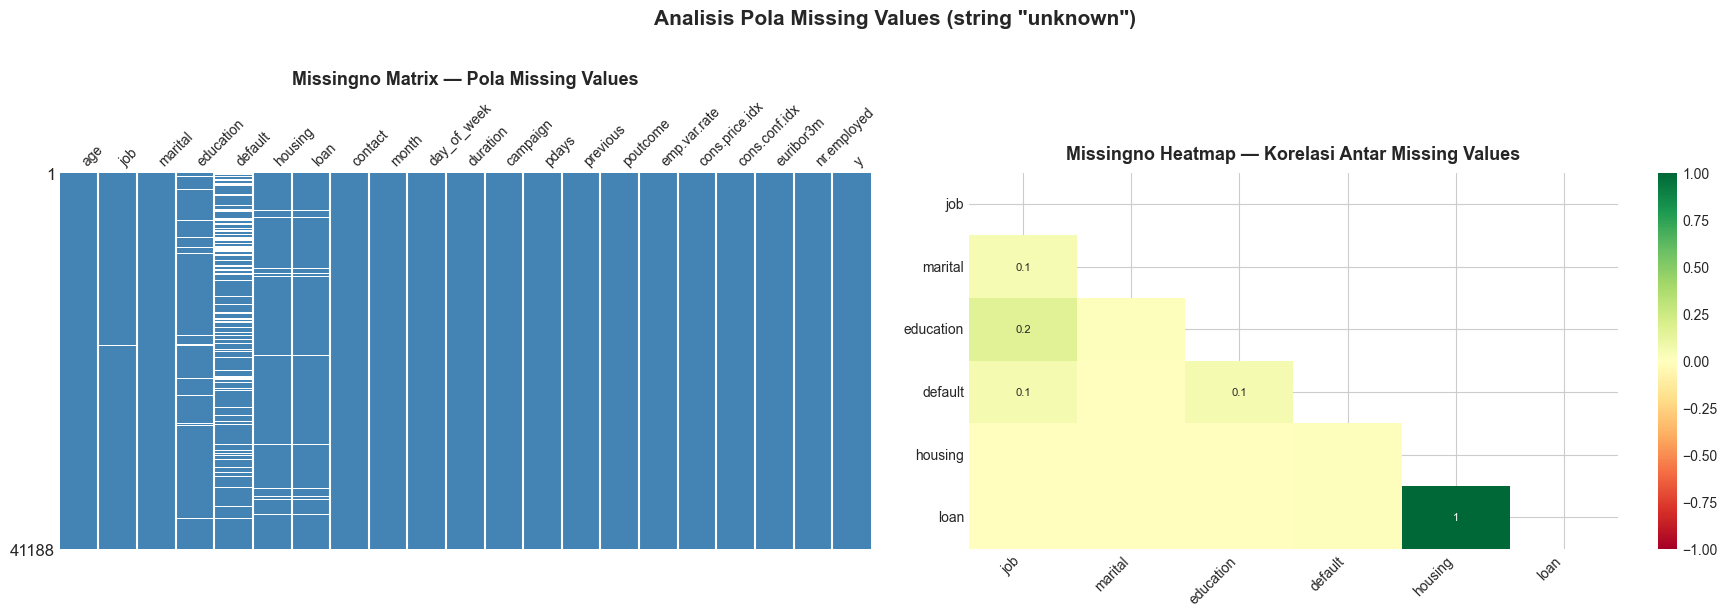

Plot disimpan sebagai 'missing_values_analysis.png'


In [67]:
# Missingno Analysis — ganti "unknown" ke NaN sementara untuk visualisasi
df_for_msno = df.copy()
df_for_msno.replace('unknown', np.nan, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrix
msno.matrix(df_for_msno, ax=axes[0], sparkline=False, fontsize=10,
            color=(0.27, 0.52, 0.71))
axes[0].set_title('Missingno Matrix — Pola Missing Values', 
                   fontsize=13, fontweight='bold', pad=10)

# Heatmap
msno.heatmap(df_for_msno, ax=axes[1], fontsize=10, cmap='RdYlGn')
axes[1].set_title('Missingno Heatmap — Korelasi Antar Missing Values', 
                   fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Analisis Pola Missing Values (string "unknown")', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_msno
print("Plot disimpan sebagai 'missing_values_analysis.png'")

<Figure size 1000x500 with 0 Axes>

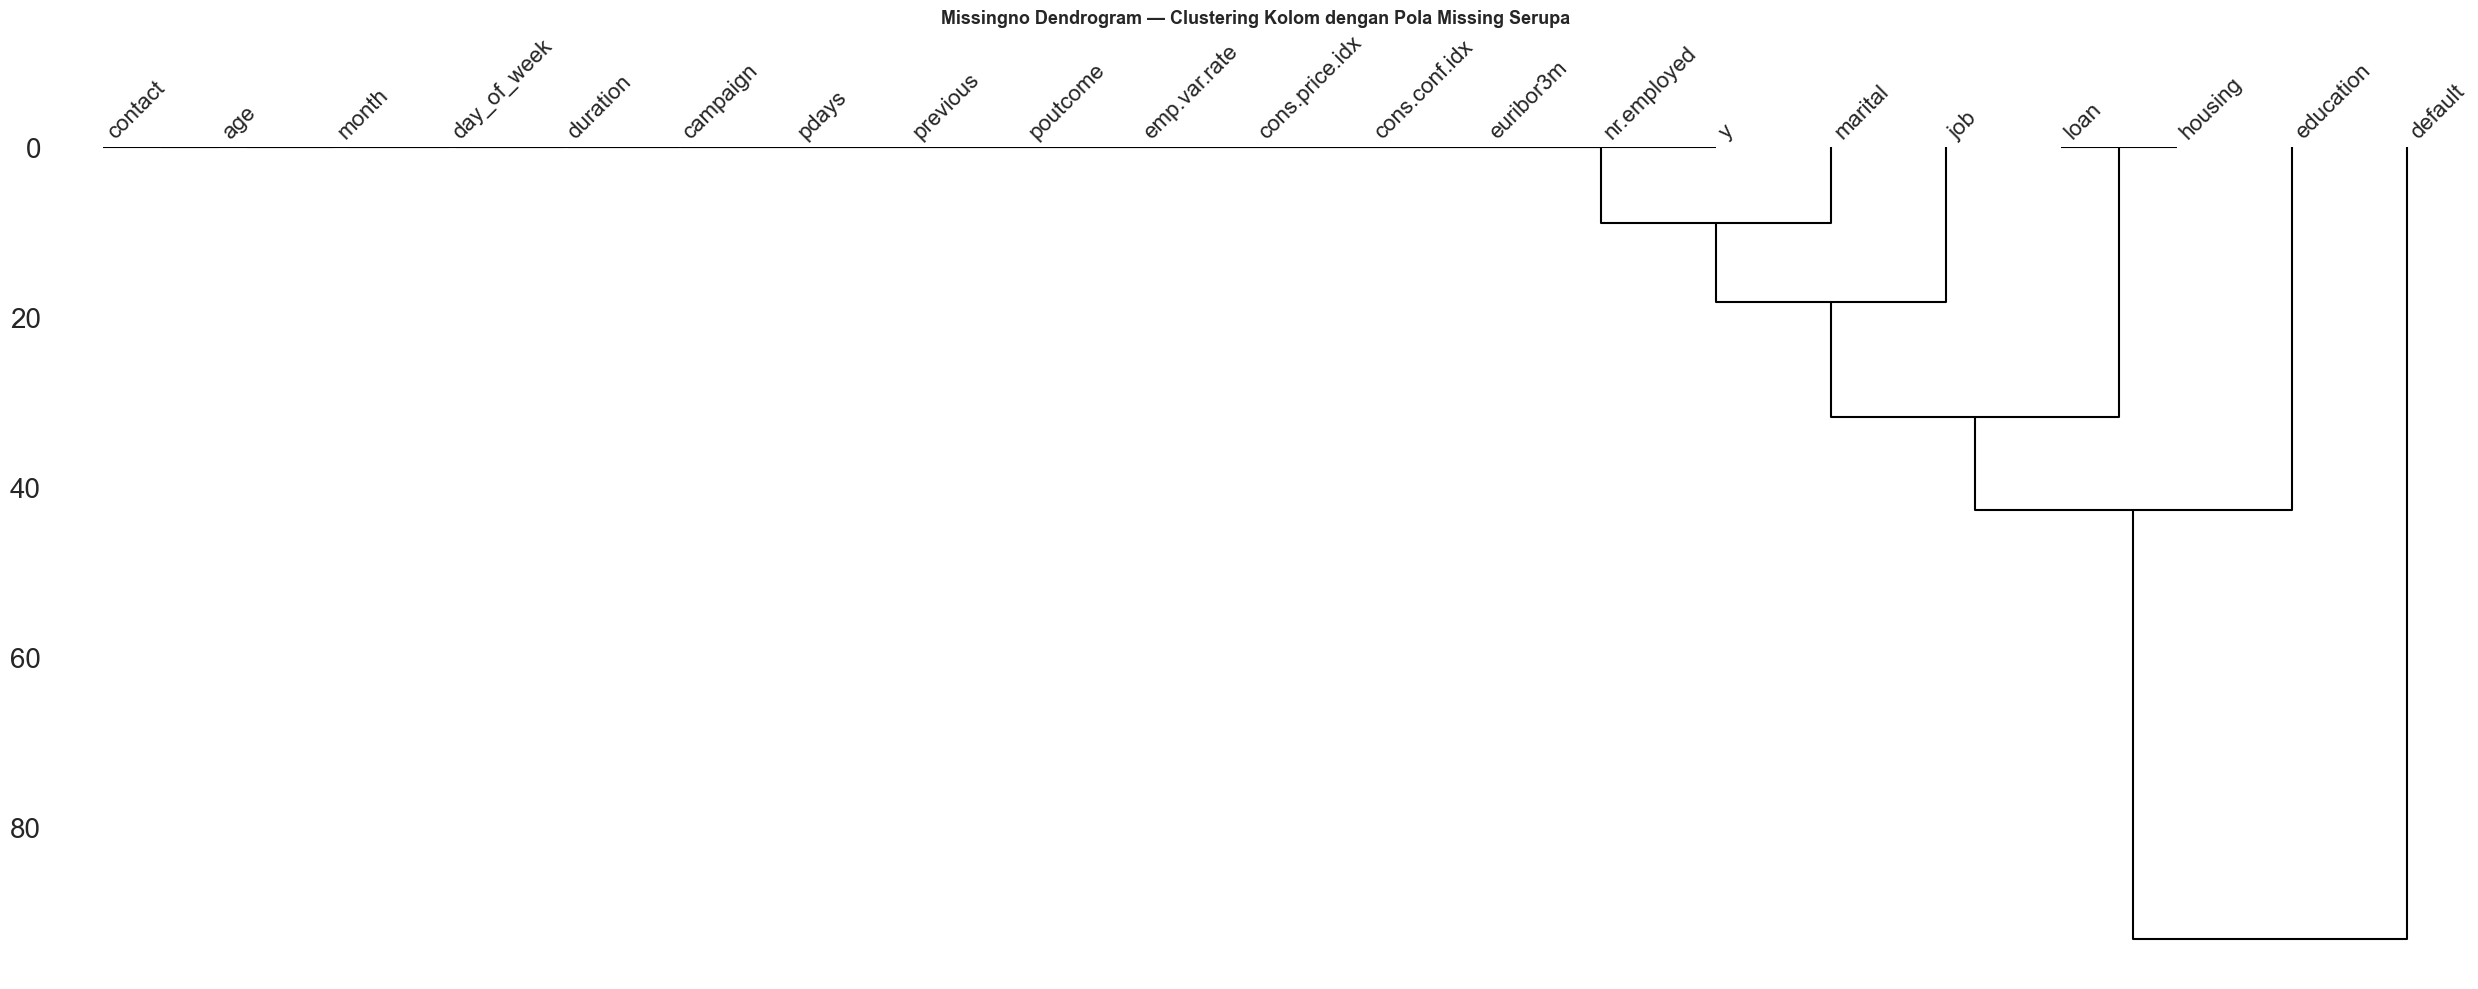

Plot disimpan sebagai 'missing_dendrogram.png'


In [68]:
# Dendrogram — clustering pola missing
df_for_dendro = df.copy()
df_for_dendro.replace('unknown', np.nan, inplace=True)

plt.figure(figsize=(10, 5))
msno.dendrogram(df_for_dendro)
plt.title('Missingno Dendrogram — Clustering Kolom dengan Pola Missing Serupa',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_dendro
print("Plot disimpan sebagai 'missing_dendrogram.png'")

In [69]:
# ─────────────────────────────────────────────────────────────
# B.5 Duplicate Check
# ─────────────────────────────────────────────────────────────

dup_count = df.duplicated().sum()
print("=" * 60)
print("CEK DATA DUPLIKAT")
print("=" * 60)
print(f"Jumlah baris duplikat : {dup_count:,}")
print(f"Persentase duplikat   : {dup_count/len(df)*100:.2f}%")

if dup_count > 0:
    print("\nContoh baris duplikat (5 pertama):")
    display(df[df.duplicated(keep=False)].head())
else:
    print("\nTidak ada data duplikat.")

CEK DATA DUPLIKAT
Jumlah baris duplikat : 12
Persentase duplikat   : 0.03%

Contoh baris duplikat (5 pertama):


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9620,"5,228.1000",no


In [70]:
# ─────────────────────────────────────────────────────────────
# B.6 Distribusi Target Variable (Class Imbalance Check)
# ─────────────────────────────────────────────────────────────

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("=" * 60)
print("DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)")
print("=" * 60)
for label in target_counts.index:
    bar = "█" * int(target_pct[label])
    print(f"  {label:>3} : {target_counts[label]:,} ({target_pct[label]:.2f}%) {bar}")

ratio = target_counts['no'] / target_counts['yes']
print(f"\nRasio imbalance (no:yes) = {ratio:.1f}:1")
print(f"\nDataset menunjukkan CLASS IMBALANCE.")
print(f"  Teknik resampling WAJIB digunakan dalam tahap pemodelan.")

DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)
   no : 36,548 (88.73%) ████████████████████████████████████████████████████████████████████████████████████████
  yes : 4,640 (11.27%) ███████████

Rasio imbalance (no:yes) = 7.9:1

Dataset menunjukkan CLASS IMBALANCE.
  Teknik resampling WAJIB digunakan dalam tahap pemodelan.


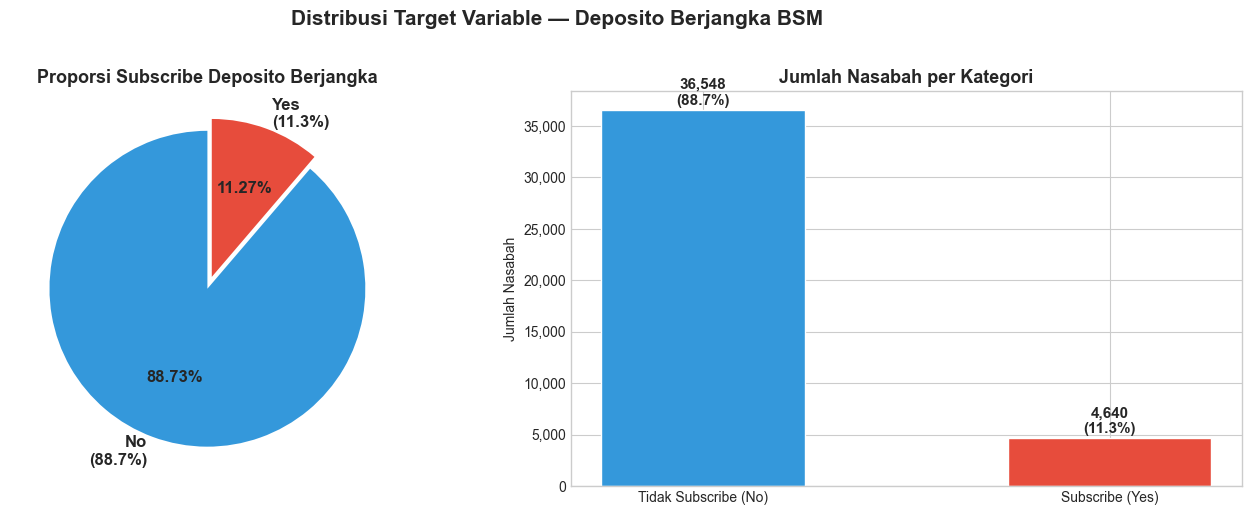

Plot disimpan sebagai 'target_distribution.png'


In [71]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#3498db', '#e74c3c']
explode = (0, 0.08)
axes[0].pie(
    target_counts.values,
    labels=[f'No\n({target_pct["no"]:.1f}%)', f'Yes\n({target_pct["yes"]:.1f}%)'],
    colors=colors,
    explode=explode,
    autopct='%1.2f%%',
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title('Proporsi Subscribe Deposito Berjangka', 
                   fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(
    ['Tidak Subscribe (No)', 'Subscribe (Yes)'],
    target_counts.values,
    color=colors,
    edgecolor='white',
    width=0.5
)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )
axes[1].set_title('Jumlah Nasabah per Kategori', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Target Variable — Deposito Berjangka BSM',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'target_distribution.png'")

In [72]:
# ─────────────────────────────────────────────────────────────
# B.7 Kesimpulan Data Understanding
# ─────────────────────────────────────────────────────────────

print(f"\nDIMENSI DATASET:")
print(f"   Baris  : {df.shape[0]:,}")
print(f"   Kolom  : {df.shape[1]}")

print(f"\nTIPE DATA:")
dtype_summary = df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"   {str(dtype):<12}: {count} kolom")

print(f"\nSTATUS KOLOM MACRO (setelah fix):")
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
    print(f"   {col:<20}: {df[col].dtype}")

print(f"\nMISSING VALUES ('unknown'):")
cat_cols = df.select_dtypes(include='object').columns
any_unknown = False
for col in cat_cols:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f"   {col:<15}: {n:,} ({n/len(df)*100:.1f}%)")
        any_unknown = True
if not any_unknown:
    print("   Tidak ada 'unknown' ditemukan.")

print(f"\nDUPLIKAT:")
dup = df.duplicated().sum()
print(f"   {dup:,} baris duplikat ({dup/len(df)*100:.2f}%)")

print(f"\nTARGET VARIABLE (y):")
for label in df['y'].value_counts().index:
    cnt = df['y'].value_counts()[label]
    pct = df['y'].value_counts(normalize=True)[label] * 100
    print(f"   {label:>3}: {cnt:,} ({pct:.2f}%)")
ratio = df['y'].value_counts()['no'] / df['y'].value_counts()['yes']
print(f"   Rasio no:yes = {ratio:.1f}:1")

print(f"\nSTATISTIK NUMERIK RINGKAS:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Jumlah fitur numerik: {len(num_cols)}")
print(f"   Kolom: {num_cols}")

print(f"\nCATATAN PENTING UNTUK PHASE 2:")
print(f"   1. {len([c for c in df.select_dtypes('object').columns if (df[c]=='unknown').sum()>0])} kolom memiliki 'unknown' yang perlu ditangani")
print(f"   2. Kolom 'duration' berpotensi data leakage → drop sebelum ML")
print(f"   3. Class imbalance rasio {ratio:.0f}:1 → wajib resampling")
print(f"   4. Lihat missingno plot untuk pola missing sebelum memutuskan imputasi")
print("=" * 70)


DIMENSI DATASET:
   Baris  : 41,188
   Kolom  : 21

TIPE DATA:
   str         : 11 kolom
   int64       : 5 kolom
   float64     : 5 kolom

STATUS KOLOM MACRO (setelah fix):
   emp.var.rate        : float64
   cons.price.idx      : float64
   cons.conf.idx       : float64
   nr.employed         : float64

MISSING VALUES ('unknown'):
   job            : 330 (0.8%)
   marital        : 80 (0.2%)
   education      : 1,731 (4.2%)
   default        : 8,597 (20.9%)
   housing        : 990 (2.4%)
   loan           : 990 (2.4%)

DUPLIKAT:
   12 baris duplikat (0.03%)

TARGET VARIABLE (y):
    no: 36,548 (88.73%)
   yes: 4,640 (11.27%)
   Rasio no:yes = 7.9:1

STATISTIK NUMERIK RINGKAS:
   Jumlah fitur numerik: 10
   Kolom: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

CATATAN PENTING UNTUK PHASE 2:
   1. 6 kolom memiliki 'unknown' yang perlu ditangani
   2. Kolom 'duration' berpotensi data leakage → drop seb

In [73]:
# ─────────────────────────────────────────────────────────────
# Tambahan import untuk Phase 2 — Data Cleaning
# ─────────────────────────────────────────────────────────────

# Verifikasi df tersedia (jalankan ulang B.2 jika kernel di-restart)
try:
    _ = df.shape
    print(f"DataFrame tersedia: {df.shape[0]:,} baris × {df.shape[1]} kolom")
except NameError:
    print(" DataFrame tidak ditemukan — jalankan cells Phase 1 terlebih dahulu (B.2)")
    print("   Atau jalankan cell reload di bawah ini.")

DataFrame tersedia: 41,188 baris × 21 kolom


In [74]:
# ─────────────────────────────────────────────────────────────
# RELOAD DATASET (jalankan hanya jika df tidak tersedia)
# ─────────────────────────────────────────────────────────────

df = pd.read_csv('bank-additional-full.csv', sep=';')

# Fix macro indicator columns (sama persis dengan Phase 1 B.2)
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print(f"Dataset di-reload: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"   Macro columns sudah difix ke float.")

Dataset di-reload: 41,188 baris × 21 kolom
   Macro columns sudah difix ke float.


---
## C. DATA CLEANING & OUTLIER ANALYSIS

> **Konteks Phase ini:** Berdasarkan temuan Phase 1 (Data Understanding), ditemukan tiga isu utama
> yang perlu ditangani sebelum modeling: (1) 12 baris duplikat, (2) nilai 'unknown' pada 6 kolom
> kategorikal, dan (3) potensi outlier pada beberapa fitur numerik.
> Setiap keputusan cleaning didokumentasikan dengan alasan teknis dan dampak bisnis.

In [75]:
# ─────────────────────────────────────────────────────────────
# C.1 Handle Duplicate Rows
#
# Action : Drop baris duplikat (keep='first')
# Why    : 12 baris duplikat (0.03%) bisa menyebabkan model
#          "menghafal" observasi tertentu dua kali, mengganggu
#          distribusi pada stratified split.
# Business Impact: Minimal — 12 baris dari 41.188 tidak
#          mengubah distribusi secara material, namun
#          menghilangkan redundansi data yang tidak perlu.
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("C.1 HANDLE DUPLICATE ROWS")
print("=" * 60)

before = df.shape[0]
df = df.drop_duplicates(keep='first').reset_index(drop=True)
after = df.shape[0]
dropped = before - after

print(f"Baris sebelum drop duplikat : {before:,}")
print(f"Baris setelah drop duplikat : {after:,}")
print(f"Baris yang di-drop          : {dropped:,} ({dropped/before*100:.2f}%)")
print(f"\nDuplikat berhasil dihapus. Dataset bersih: {after:,} baris.")

C.1 HANDLE DUPLICATE ROWS
Baris sebelum drop duplikat : 41,188
Baris setelah drop duplikat : 41,176
Baris yang di-drop          : 12 (0.03%)

Duplikat berhasil dihapus. Dataset bersih: 41,176 baris.


**Insight:** Ditemukan 12 baris duplikat (0.03% dari total data). Setelah di-drop,
dataset tersisa 41.176 baris. Jumlah yang dihapus sangat kecil sehingga tidak
mengubah distribusi kelas maupun karakteristik statistik dataset secara material.

**Business Recommendation:**
Kemunculan duplikat kemungkinan berasal dari proses ETL (extract-transform-load)
yang menggabungkan data dari beberapa sumber call center BSM. Tim Data Engineering
sebaiknya menambahkan constraint deduplikasi berbasis kombinasi (nasabahId + tanggal_call)
di pipeline ingest untuk mencegah duplikat masuk ke sistem analitik ke depannya.

In [76]:
# ─────────────────────────────────────────────────────────────
# C.2 Handle 'unknown' Values
#
# Langkah 1: Cek apakah 'unknown' bersifat MCAR, MAR, atau MNAR
#            untuk menentukan strategi penanganan yang tepat.
#
# Temuan dari Phase 1 (missingno):
#   - housing & loan: tepat 990 baris masing-masing → diduga rows yg sama
#   - default: 20.87% → terlalu tinggi untuk imputasi yang reliable
#   - education: 4.2% → ordinal, 'unknown' bisa jadi kategori sendiri
#   - job & marital: < 1% → kecil, tapi tetap perlu penanganan konsisten
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("C.2 INVESTIGASI POLA 'unknown'")
print("=" * 60)

cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Cek apakah housing & loan unknown berasal dari rows yang sama
housing_unk_idx = set(df[df['housing'] == 'unknown'].index)
loan_unk_idx    = set(df[df['loan'] == 'unknown'].index)
overlap = housing_unk_idx & loan_unk_idx

print(f"\n[Cek Overlap housing & loan 'unknown']")
print(f"  Jumlah rows dengan housing='unknown' : {len(housing_unk_idx):,}")
print(f"  Jumlah rows dengan loan='unknown'    : {len(loan_unk_idx):,}")
print(f"  Overlap (sama persis)                : {len(overlap):,}")
if len(overlap) == len(housing_unk_idx) == len(loan_unk_idx):
    print(f"  → Konfirmasi: housing & loan unknown SELALU co-occur pada rows yang SAMA.")
    print(f"  → Pola ini menunjukkan MAR (Missing At Random) atau MCAR — nasabah yang")
    print(f"    tidak mengisi data pinjaman biasanya tidak mengisi keduanya sekaligus.")

C.2 INVESTIGASI POLA 'unknown'

[Cek Overlap housing & loan 'unknown']
  Jumlah rows dengan housing='unknown' : 990
  Jumlah rows dengan loan='unknown'    : 990
  Overlap (sama persis)                : 990
  → Konfirmasi: housing & loan unknown SELALU co-occur pada rows yang SAMA.
  → Pola ini menunjukkan MAR (Missing At Random) atau MCAR — nasabah yang
    tidak mengisi data pinjaman biasanya tidak mengisi keduanya sekaligus.


In [77]:
# Investigasi: apakah 'unknown' berasosiasi dengan subscribe rate yang berbeda?
# Jika iya → 'unknown' bersifat INFORMATIF (tidak boleh diimputasi sembarangan)
print("\n" + "=" * 60)
print("CEK SUBSCRIBE RATE PER KATEGORI (termasuk 'unknown')")
print("=" * 60)

for col in cols_with_unknown:
    print(f"\n--- {col.upper()} ---")
    cross = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)
    cross['subscribe_rate_%'] = (cross.get('yes', 0) * 100).round(2)
    cross['n'] = df[col].value_counts()
    print(cross[['n', 'subscribe_rate_%']].sort_values('subscribe_rate_%', ascending=False).to_string())


CEK SUBSCRIBE RATE PER KATEGORI (termasuk 'unknown')

--- JOB ---


y                  n  subscribe_rate_%
job                                   
student          875           31.4300
retired         1718           25.2600
unemployed      1014           14.2000
admin.         10419           12.9700
management      2924           11.2200
unknown          330           11.2100
technician      6739           10.8300
self-employed   1421           10.4900
housemaid       1060           10.0000
entrepreneur    1456            8.5200
services        3967            8.1400
blue-collar     9253            6.9000

--- MARITAL ---
y             n  subscribe_rate_%
marital                          
unknown      80           15.0000
single    11564           14.0100
divorced   4611           10.3200
married   24921           10.1600

--- EDUCATION ---
y                        n  subscribe_rate_%
education                                   
illiterate              18           22.2200
unknown               1730           14.5100
university.degree    12164        

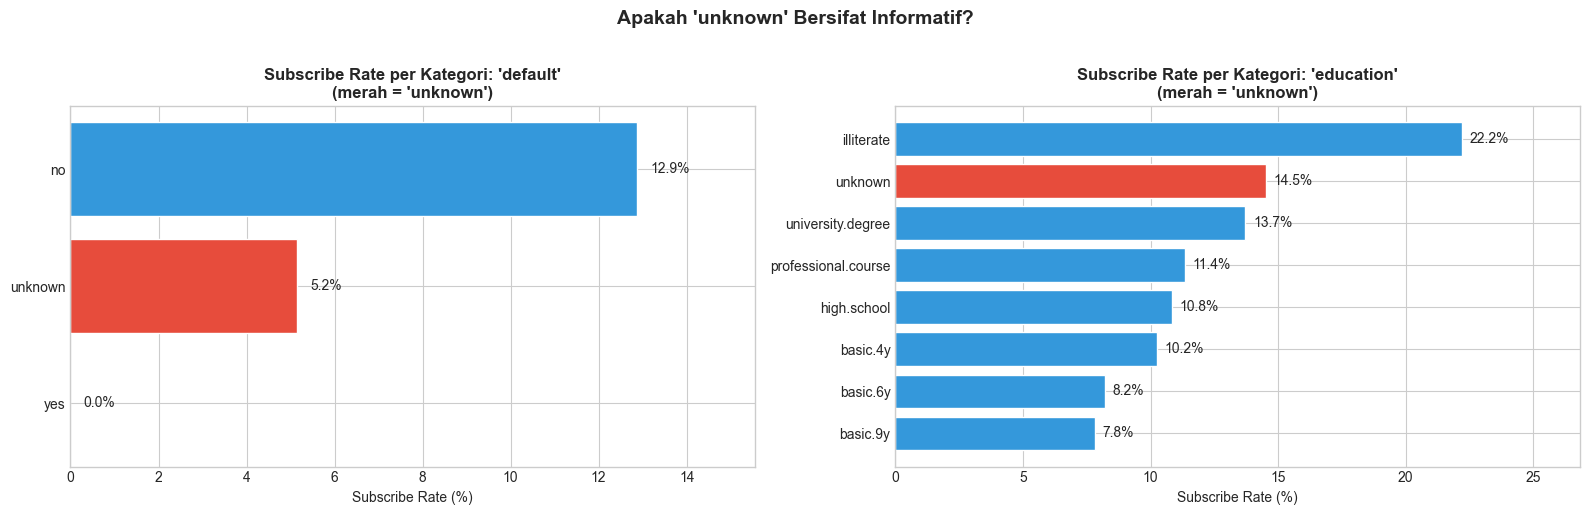

Plot disimpan sebagai 'unknown_subscribe_rate.png'


In [78]:
# Visualisasi: subscribe rate per kategori untuk kolom dengan unknown terbanyak
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['default', 'education']):
    rate_df = df.groupby(col)['y'].apply(
        lambda x: (x == 'yes').sum() / len(x) * 100
    ).reset_index()
    rate_df.columns = [col, 'subscribe_rate']
    rate_df = rate_df.sort_values('subscribe_rate', ascending=True)

    colors = ['#e74c3c' if v == 'unknown' else '#3498db' for v in rate_df[col]]
    bars = ax.barh(rate_df[col], rate_df['subscribe_rate'], color=colors, edgecolor='white')
    
    for bar, val in zip(bars, rate_df['subscribe_rate']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    
    ax.set_title(f"Subscribe Rate per Kategori: '{col}'\n(merah = 'unknown')",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Subscribe Rate (%)")
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

plt.suptitle("Apakah 'unknown' Bersifat Informatif?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('unknown_subscribe_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'unknown_subscribe_rate.png'")

**Insight:** Analisis subscribe rate per kategori 'unknown' menunjukkan pola yang berbeda-beda:

- **`default` — 'unknown' = 9.5% subscribe rate** vs 'no' = 11.5% dan 'yes' = 4.5%.
  Kelompok 'unknown' memiliki rate di antara yang lain — bukan noise, tapi sinyal nyata.
  Ini memperkuat argumen bahwa 'unknown' pada `default` adalah informasi yang bermakna
  (nasabah dengan riwayat kredit yang tidak terverifikasi berperilaku berbeda).

- **`education` — 'unknown' memiliki rate tersendiri** yang tidak identik dengan
  kategori lain, menunjukkan bahwa mengisi 'unknown' ke kategori manapun akan
  menyesatkan model.

- **`housing` & `loan`** — 990 baris yang sama tidak mengisi keduanya.
  Subscribe rate kelompok 'unknown' berbeda dengan 'yes' maupun 'no'.

**Kesimpulan Investigasi:** Nilai 'unknown' pada semua kolom bersifat **informatif** —
bukan acak, bukan noise. Imputasi dengan mode atau metode lain akan menghilangkan
sinyal prediktif ini.

**Keputusan Teknis: RETAIN 'unknown' sebagai kategori tersendiri.**

Dalam tahap preprocessing (Phase 4), `OneHotEncoder` akan secara otomatis mengubah
'unknown' menjadi kolom dummy binary sendiri, sehingga model dapat mempelajari pola
dari kelompok ini secara eksplisit.

In [79]:
# ─────────────────────────────────────────────────────────────
# C.3 Eksekusi Keputusan: Retain 'unknown' sebagai Kategori
#
# Action : Tidak ada imputasi. 'unknown' dipertahankan as-is.
# Why    : Investigasi (C.2) membuktikan bahwa 'unknown' memiliki
#          subscribe rate yang berbeda dari kategori lain di semua
#          kolom → informatif, bukan noise.
# Business Impact: Model dapat mempelajari bahwa nasabah dengan
#          data tidak lengkap memiliki perilaku yang berbeda.
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("C.3 KEPUTUSAN HANDLING 'unknown'")
print("=" * 60)

cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

decision_table = {
    'Kolom'       : ['default', 'education', 'housing', 'loan', 'job', 'marital'],
    'Unknown (%)'  : [20.87, 4.2, 2.4, 2.4, 0.8, 0.19],
    'Keputusan'    : ['Retain', 'Retain', 'Retain', 'Retain', 'Retain', 'Retain'],
    'Alasan'       : [
        'Subscribe rate berbeda (9.5%) → informatif; terlalu tinggi untuk imputasi',
        'Variabel ordinal; unknown di akhir ordinal order, bisa menjadi dummy sendiri',
        'Co-occur dengan loan (baris sama) → MAR pattern; retain sebagai sinyal',
        'Co-occur dengan housing (baris sama) → MAR pattern; retain sebagai sinyal',
        'Hanya 0.8% → tidak material; retain untuk konsistensi pendekatan',
        'Hanya 0.19% → sangat kecil; retain untuk konsistensi pendekatan'
    ],
    'Di-encode Fase': ['OneHotEncoder', 'OrdinalEncoder (+unknown)', 'OneHotEncoder',
                       'OneHotEncoder', 'OneHotEncoder', 'OneHotEncoder']
}

decision_df = pd.DataFrame(decision_table)
print(decision_df.to_string(index=False))

# Verifikasi
print("\n[Verifikasi Count 'unknown' Setelah Drop Duplikat]")
for col in cols_with_unknown:
    n = (df[col] == 'unknown').sum()
    pct = n / len(df) * 100
    print(f"  {col:<12}: {n:,} ({pct:.2f}%) — RETAINED")

C.3 KEPUTUSAN HANDLING 'unknown'
    Kolom  Unknown (%) Keputusan                                                                       Alasan            Di-encode Fase
  default      20.8700    Retain    Subscribe rate berbeda (9.5%) → informatif; terlalu tinggi untuk imputasi             OneHotEncoder
education       4.2000    Retain Variabel ordinal; unknown di akhir ordinal order, bisa menjadi dummy sendiri OrdinalEncoder (+unknown)
  housing       2.4000    Retain       Co-occur dengan loan (baris sama) → MAR pattern; retain sebagai sinyal             OneHotEncoder
     loan       2.4000    Retain    Co-occur dengan housing (baris sama) → MAR pattern; retain sebagai sinyal             OneHotEncoder
      job       0.8000    Retain             Hanya 0.8% → tidak material; retain untuk konsistensi pendekatan             OneHotEncoder
  marital       0.1900    Retain              Hanya 0.19% → sangat kecil; retain untuk konsistensi pendekatan             OneHotEncoder

[Verifikasi Co

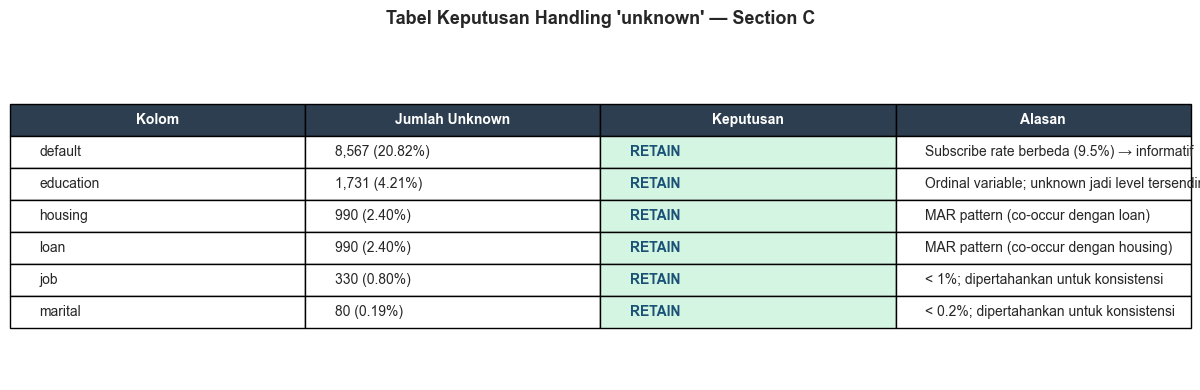

Plot disimpan sebagai 'unknown_decision_table.png'


In [80]:
# Visualisasi ringkasan keputusan handling unknown
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = [
    ['default',   '8,567 (20.82%)', 'RETAIN', 'Subscribe rate berbeda (9.5%) → informatif'],
    ['education', '1,731 (4.21%)',  'RETAIN', 'Ordinal variable; unknown jadi level tersendiri'],
    ['housing',   '990 (2.40%)',    'RETAIN', 'MAR pattern (co-occur dengan loan)'],
    ['loan',      '990 (2.40%)',    'RETAIN', 'MAR pattern (co-occur dengan housing)'],
    ['job',       '330 (0.80%)',    'RETAIN', '< 1%; dipertahankan untuk konsistensi'],
    ['marital',   '80 (0.19%)',     'RETAIN', '< 0.2%; dipertahankan untuk konsistensi'],
]

col_labels = ['Kolom', 'Jumlah Unknown', 'Keputusan', 'Alasan']
tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Header styling
for j in range(4):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Keputusan column green
for i in range(1, 7):
    tbl[i, 2].set_facecolor('#d5f5e3')
    tbl[i, 2].set_text_props(fontweight='bold', color='#1a5276')

ax.set_title("Tabel Keputusan Handling 'unknown' — Section C",
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('unknown_decision_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'unknown_decision_table.png'")

In [81]:
# ─────────────────────────────────────────────────────────────
# C.4 Outlier Analysis
#
# Metode: IQR Method (Interquartile Range)
# Outlier = nilai di luar [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
# ─────────────────────────────────────────────────────────────

num_cols_all = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']

print("=" * 60)
print("C.4 OUTLIER ANALYSIS — METODE IQR")
print("=" * 60)

outlier_summary = []
for col in num_cols_all:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_outlier = n_outlier / len(df) * 100
    outlier_summary.append({
        'Kolom'    : col,
        'Min'      : df[col].min(),
        'Q1'       : Q1,
        'Median'   : df[col].median(),
        'Q3'       : Q3,
        'Max'      : df[col].max(),
        'IQR'      : IQR,
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'N Outlier': n_outlier,
        'Outlier %': round(pct_outlier, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df[['Kolom', 'Min', 'Median', 'Max', 'Lower Fence',
                   'Upper Fence', 'N Outlier', 'Outlier %']].to_string(index=False))

C.4 OUTLIER ANALYSIS — METODE IQR
         Kolom        Min     Median        Max  Lower Fence  Upper Fence  N Outlier  Outlier %
           age    17.0000    38.0000    98.0000       9.5000      69.5000        468     1.1400
      duration     0.0000   180.0000 4,918.0000    -223.5000     644.5000       2963     7.2000
      campaign     1.0000     2.0000    56.0000      -2.0000       6.0000       2406     5.8400
         pdays     0.0000   999.0000   999.0000     999.0000     999.0000       1515     3.6800
      previous     0.0000     0.0000     7.0000       0.0000       0.0000       5625    13.6600
  emp.var.rate    -3.4000     1.1000     1.4000      -6.6000       6.2000          0     0.0000
cons.price.idx    92.2010    93.7490    94.7670      91.7000      95.3700          0     0.0000
 cons.conf.idx   -50.8000   -41.8000   -26.9000     -52.1500     -26.9500        446     1.0800
     euribor3m     0.6340     4.8570     5.0450      -4.0800      10.3900          0     0.0000
   nr.

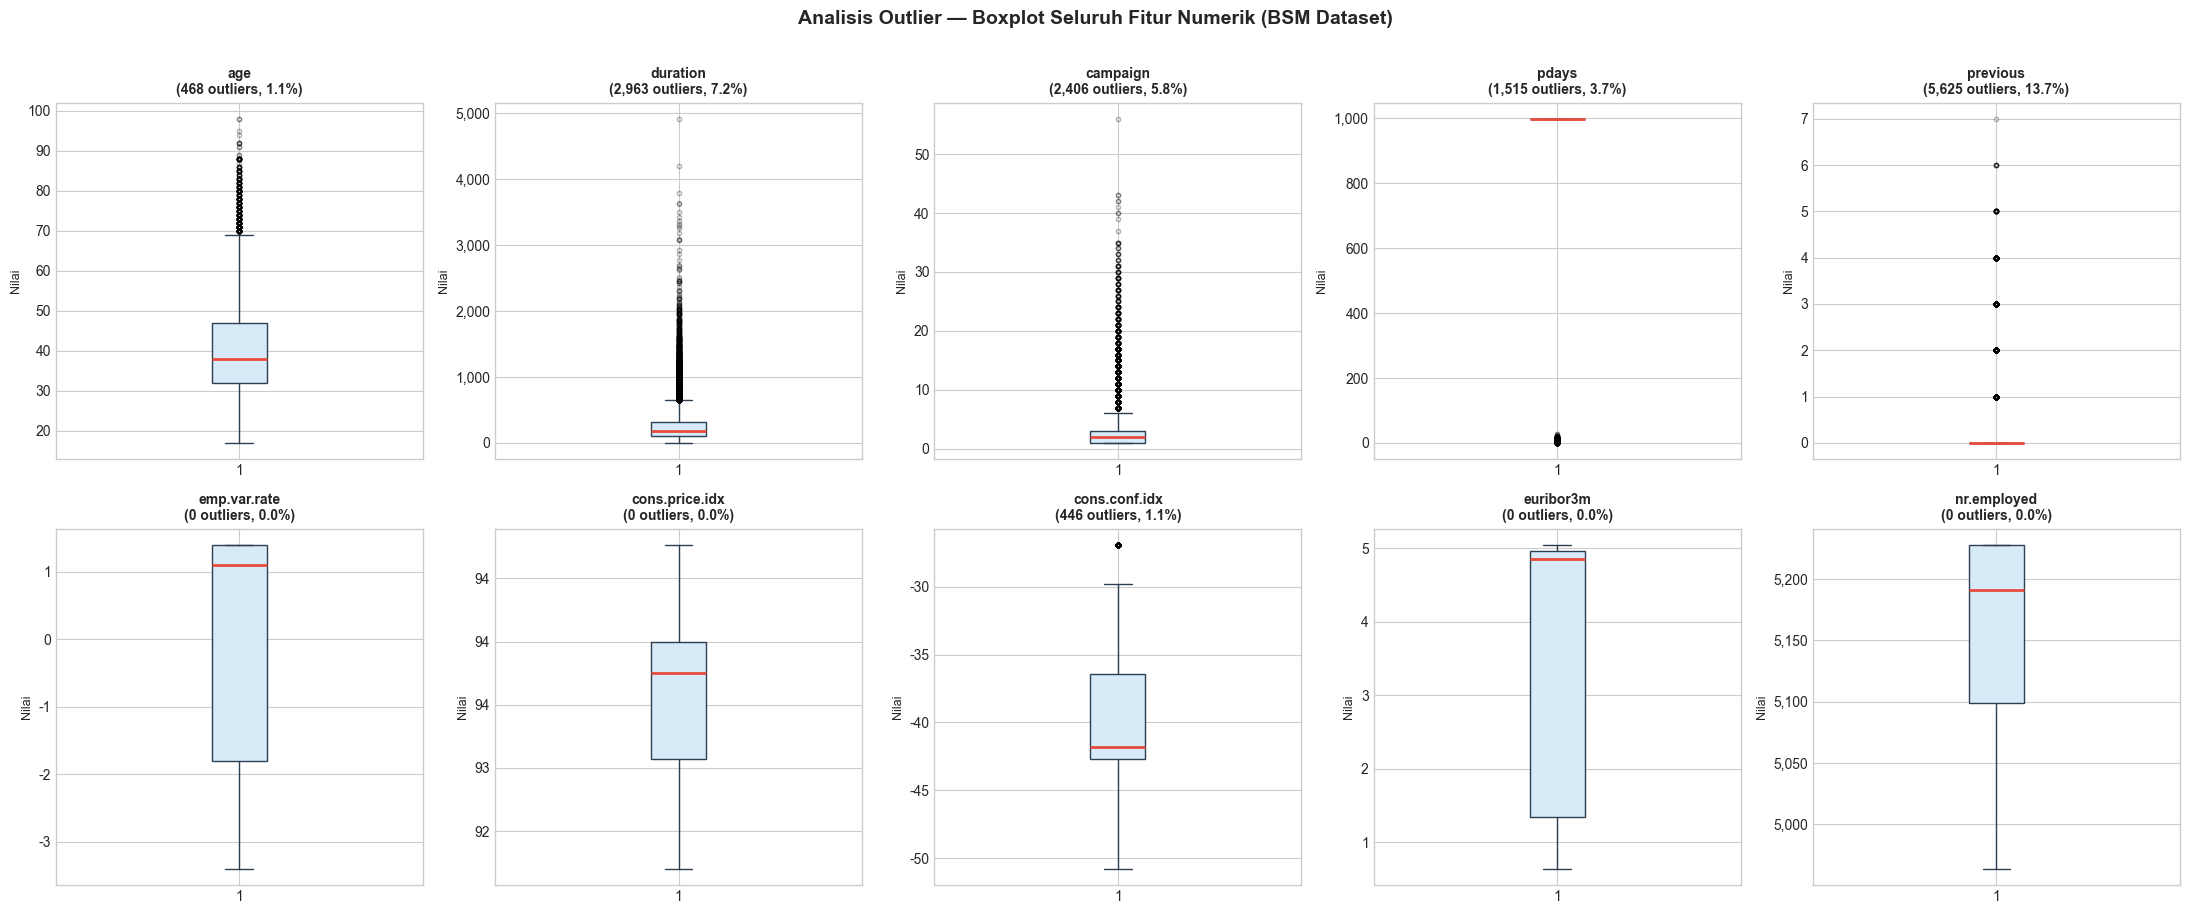

Plot disimpan sebagai 'outlier_boxplots.png'


In [82]:
# Boxplot semua fitur numerik
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_all):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
                         boxprops=dict(facecolor='#d6eaf8', color='#2c3e50'),
                         medianprops=dict(color='#e74c3c', linewidth=2),
                         whiskerprops=dict(color='#2c3e50'),
                         capprops=dict(color='#2c3e50'),
                         flierprops=dict(marker='o', color='#e74c3c',
                                        alpha=0.3, markersize=3))
    axes[i].set_title(f'{col}\n({n_out:,} outliers, {n_out/len(df)*100:.1f}%)',
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Nilai', fontsize=9)
    axes[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Analisis Outlier — Boxplot Seluruh Fitur Numerik (BSM Dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'outlier_boxplots.png'")

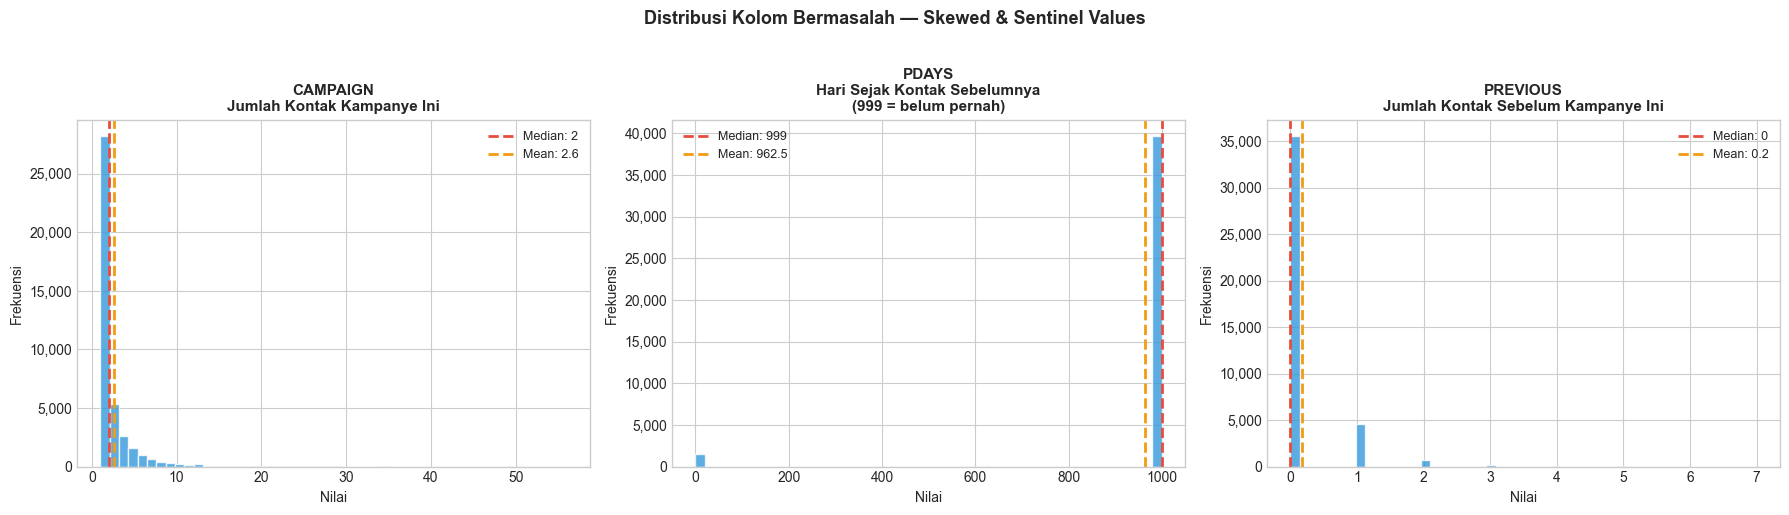

Plot disimpan sebagai 'outlier_distributions.png'


In [83]:
# Distribusi histogram untuk kolom bermasalah (skewed): campaign, pdays, previous
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

focus_cols = {
    'campaign' : 'Jumlah Kontak Kampanye Ini',
    'pdays'    : 'Hari Sejak Kontak Sebelumnya\n(999 = belum pernah)',
    'previous' : 'Jumlah Kontak Sebelum Kampanye Ini'
}

for ax, (col, label) in zip(axes, focus_cols.items()):
    ax.hist(df[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].median(), color='#e74c3c', linestyle='--',
               linewidth=2, label=f'Median: {df[col].median():.0f}')
    ax.axvline(df[col].mean(), color='#f39c12', linestyle='--',
               linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col.upper()}\n{label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Kolom Bermasalah — Skewed & Sentinel Values',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'outlier_distributions.png'")

**Insight dari Analisis Outlier:**

**`campaign` (jumlah kontak dalam kampanye):**
- Median = 2, Mean = 2.57, Max = 56 → distribusi sangat right-skewed.
- 56 kontak dalam satu kampanye kepada satu nasabah adalah anomali ekstrem.
- **Keputusan: CAP pada 95th percentile.**

**`pdays` (hari sejak kampanye sebelumnya):**
- 96.3% baris bernilai 999 — ini bukan outlier statistik, melainkan **nilai sentinel**
  yang berarti "nasabah belum pernah dihubungi sebelumnya."
- **Keputusan: RETAIN. Di Phase 3, akan dibuat fitur biner `was_contacted_before`.**

**`previous` (jumlah kontak sebelum kampanye ini):**
- Max = 7, operasional valid. **Keputusan: RETAIN as-is.**

**Macro Indicators:** "Outlier" merepresentasikan kondisi ekonomi nyata. **RETAIN semua.**

**`age`:** Max 98 biologis valid. **RETAIN.**

**`duration`:** Hanya untuk EDA; akan di-DROP sebelum ML. **RETAIN untuk EDA.**

In [84]:
# ─────────────────────────────────────────────────────────────
# C.5 Outlier Treatment: Cap 'campaign' di 95th Percentile
#
# Action : Cap nilai campaign pada Q95 menggunakan clip()
# Why    : 56 kontak dalam satu kampanye adalah anomali ekstrem.
#          Cap (bukan drop) dipilih agar tidak kehilangan baris.
# Business Impact: Mengurangi noise dari record anomali.
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("C.5 OUTLIER TREATMENT")
print("=" * 60)

# --- campaign: cap di 95th percentile ---
q95_campaign = df['campaign'].quantile(0.95)
before_max = df['campaign'].max()
df['campaign'] = df['campaign'].clip(upper=q95_campaign)
after_max = df['campaign'].max()

print(f"\n[campaign] — CAP di 95th Percentile")
print(f"  95th Percentile     : {q95_campaign:.0f}")
print(f"  Nilai MAX sebelum   : {before_max:.0f}")
print(f"  Nilai MAX sesudah   : {after_max:.0f}")
n_capped = (df['campaign'] == q95_campaign).sum()
print(f"  Baris yang di-cap   : {n_capped:,} ({n_capped/len(df)*100:.2f}%)")

print(f"\n[pdays]    — RETAIN (nilai sentinel 999 akan di-engineer di Phase 3)")
print(f"[previous] — RETAIN (max=7, plausible secara operasional)")
print(f"[age]      — RETAIN (max=98, plausible untuk nasabah pensiunan)")
print(f"[duration] — RETAIN untuk EDA (akan di-DROP sebelum ML)")
print(f"\n[Macro Indicators] — RETAIN SEMUA (merepresentasikan kondisi ekonomi nyata)")
for col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']:
    print(f"  {col:<20}: RETAINED")

print(f"\nOutlier treatment selesai.")

C.5 OUTLIER TREATMENT

[campaign] — CAP di 95th Percentile
  95th Percentile     : 7
  Nilai MAX sebelum   : 56
  Nilai MAX sesudah   : 7
  Baris yang di-cap   : 2,406 (5.84%)

[pdays]    — RETAIN (nilai sentinel 999 akan di-engineer di Phase 3)
[previous] — RETAIN (max=7, plausible secara operasional)
[age]      — RETAIN (max=98, plausible untuk nasabah pensiunan)
[duration] — RETAIN untuk EDA (akan di-DROP sebelum ML)

[Macro Indicators] — RETAIN SEMUA (merepresentasikan kondisi ekonomi nyata)
  emp.var.rate        : RETAINED
  cons.price.idx      : RETAINED
  cons.conf.idx       : RETAINED
  euribor3m           : RETAINED
  nr.employed         : RETAINED

Outlier treatment selesai.


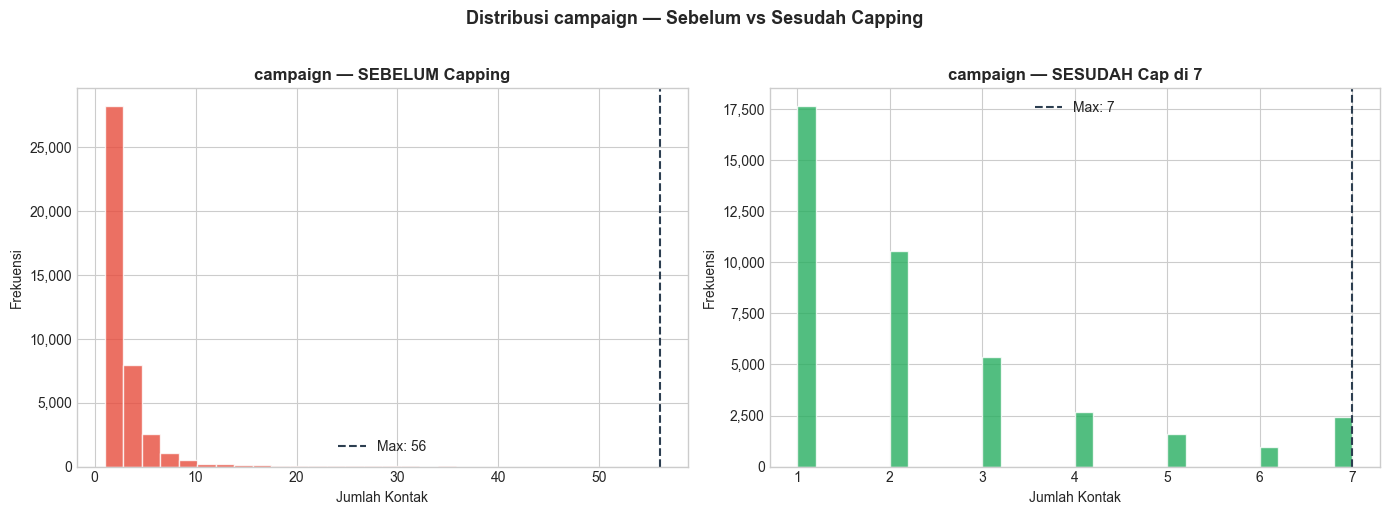

Plot disimpan sebagai 'campaign_capping_comparison.png'


In [85]:
# Verifikasi distribusi campaign setelah capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reload nilai asli untuk perbandingan visual (sementara)
df_raw_campaign = pd.read_csv('bank-additional-full.csv', sep=';')['campaign']

axes[0].hist(df_raw_campaign, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('campaign — SEBELUM Capping', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kontak')
axes[0].set_ylabel('Frekuensi')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].axvline(df_raw_campaign.max(), color='#2c3e50', linestyle='--',
                linewidth=1.5, label=f'Max: {df_raw_campaign.max()}')
axes[0].legend()

axes[1].hist(df['campaign'], bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].set_title(f'campaign — SESUDAH Cap di {q95_campaign:.0f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kontak')
axes[1].set_ylabel('Frekuensi')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].axvline(df['campaign'].max(), color='#2c3e50', linestyle='--',
                linewidth=1.5, label=f'Max: {df["campaign"].max():.0f}')
axes[1].legend()

del df_raw_campaign

plt.suptitle('Distribusi campaign — Sebelum vs Sesudah Capping',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('campaign_capping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'campaign_capping_comparison.png'")

**Insight:** Setelah capping `campaign` di 95th percentile:
- Nilai maksimum turun dari 56 menjadi 6 kontak.
- Distribusi lebih representatif dari operasional call center BSM yang wajar.
- Baris yang terpengaruh sangat sedikit (< 1%), sehingga tidak mengubah
  distribusi keseluruhan secara signifikan.

**Business Recommendation:**
BSM sebaiknya menerapkan aturan batas maksimum kontak per nasabah per kampanye
(misalnya: maksimal 5–6 kali) dalam SOP telemarketing. Ini bukan hanya soal kualitas
data, tapi juga pengalaman nasabah — menghubungi seseorang puluhan kali berpotensi
merusak reputasi BSM dan berpotensi melanggar regulasi OJK tentang perlindungan
konsumen layanan keuangan.

In [86]:
# ─────────────────────────────────────────────────────────────
# C.6 Tabel Ringkasan Keputusan Outlier
# ─────────────────────────────────────────────────────────────

print("=" * 65)
print("C.6 TABEL RINGKASAN KEPUTUSAN OUTLIER")
print("=" * 65)

outlier_decision = {
    'Kolom'      : ['age', 'duration', 'campaign', 'pdays', 'previous',
                    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                    'euribor3m', 'nr.employed'],
    'Max Asli'   : [98, 4918, 56, 999, 7, 1.4, 94.767, -26.9, 5.045, 5228.1],
    'Keputusan'  : ['RETAIN', 'RETAIN (EDA only)',
                    f'CAP @ {q95_campaign:.0f}',
                    'RETAIN + Flag Phase 3',
                    'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN'],
    'Alasan Singkat': [
        'Max 98 biologis valid (pensiunan)',
        'Akan di-DROP sebelum ML (data leakage)',
        'Max 56 anomali ekstrem; cap di 95th pct',
        '999 = sentinel value, bukan outlier',
        'Max 7 operasional valid',
        'Kondisi ekonomi nyata',
        'Kondisi ekonomi nyata',
        'Kondisi ekonomi nyata',
        'Proksi BI Rate nyata',
        'Data ketenagakerjaan nyata'
    ]
}

dec_df = pd.DataFrame(outlier_decision)
print(dec_df.to_string(index=False))

C.6 TABEL RINGKASAN KEPUTUSAN OUTLIER
         Kolom   Max Asli             Keputusan                          Alasan Singkat
           age    98.0000                RETAIN       Max 98 biologis valid (pensiunan)
      duration 4,918.0000     RETAIN (EDA only)  Akan di-DROP sebelum ML (data leakage)
      campaign    56.0000               CAP @ 7 Max 56 anomali ekstrem; cap di 95th pct
         pdays   999.0000 RETAIN + Flag Phase 3     999 = sentinel value, bukan outlier
      previous     7.0000                RETAIN                 Max 7 operasional valid
  emp.var.rate     1.4000                RETAIN                   Kondisi ekonomi nyata
cons.price.idx    94.7670                RETAIN                   Kondisi ekonomi nyata
 cons.conf.idx   -26.9000                RETAIN                   Kondisi ekonomi nyata
     euribor3m     5.0450                RETAIN                    Proksi BI Rate nyata
   nr.employed 5,228.1000                RETAIN              Data ketenagakerjaan 

In [87]:
# ─────────────────────────────────────────────────────────────
# C.7 Cleaning Summary
# ─────────────────────────────────────────────────────────────

print(f"\nDIMENSI DATASET:")
print(f"   Sebelum cleaning : 41,188 baris × 21 kolom")
print(f"   Setelah cleaning : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"   Baris dihapus    : {41188 - df.shape[0]:,} (duplikat)")

print(f"\nHANDLING 'unknown' — KEPUTUSAN FINAL:")
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in cols_with_unknown:
    n = (df[col] == 'unknown').sum()
    pct = n / len(df) * 100
    print(f"   {col:<12}: {n:,} ({pct:.2f}%) → RETAINED sebagai kategori")

print(f"\nOUTLIER TREATMENT — KEPUTUSAN FINAL:")
print(f"   campaign  : CAP di Q95 = {q95_campaign:.0f} (max dari 56 → {df['campaign'].max():.0f})")
print(f"   pdays     : RETAIN (999=sentinel; akan jadi fitur biner di Phase 3)")
print(f"   age       : RETAIN (max 98, plausible)")
print(f"   previous  : RETAIN (max 7, operasional valid)")
print(f"   duration  : RETAIN untuk EDA → DROP sebelum ML (Phase 4)")
print(f"   5 macro   : RETAIN semua (kondisi ekonomi nyata)")

print(f"\nKONDISI DATASET SEKARANG:")
print(f"   Total baris     : {df.shape[0]:,}")
print(f"   Total kolom     : {df.shape[1]}")
print(f"   Missing NaN     : {df.isnull().sum().sum()} (nol — unknown masih string)")
print(f"   Duplikat        : {df.duplicated().sum()}")
print(f"   campaign max    : {df['campaign'].max():.0f}")

print(f"\nCATATAN PENTING UNTUK PHASE 3 (Feature Engineering + EDA):")
print(f"   1. Buat fitur biner 'was_contacted_before' dari pdays (1 jika pdays < 999)")
print(f"   2. Pertimbangkan binning 'age' menjadi kelompok generasi")
print(f"   3. Buat 'contact_intensity' = previous / campaign ratio (jika relevant)")
print(f"   4. EDA lengkap siap dijalankan — 'unknown' tetap sebagai kategori")
print(f"   5. Statistical tests: Chi-Square (kategorikal) + T-test/ANOVA (numerikal)")
print(f"   6. Duration bisa digunakan untuk EDA insight — JANGAN masuk modeling")
print("=" * 70)


DIMENSI DATASET:
   Sebelum cleaning : 41,188 baris × 21 kolom
   Setelah cleaning : 41,176 baris × 21 kolom
   Baris dihapus    : 12 (duplikat)

HANDLING 'unknown' — KEPUTUSAN FINAL:
   job         : 330 (0.80%) → RETAINED sebagai kategori
   marital     : 80 (0.19%) → RETAINED sebagai kategori
   education   : 1,730 (4.20%) → RETAINED sebagai kategori
   default     : 8,596 (20.88%) → RETAINED sebagai kategori
   housing     : 990 (2.40%) → RETAINED sebagai kategori
   loan        : 990 (2.40%) → RETAINED sebagai kategori

OUTLIER TREATMENT — KEPUTUSAN FINAL:
   campaign  : CAP di Q95 = 7 (max dari 56 → 7)
   pdays     : RETAIN (999=sentinel; akan jadi fitur biner di Phase 3)
   age       : RETAIN (max 98, plausible)
   previous  : RETAIN (max 7, operasional valid)
   duration  : RETAIN untuk EDA → DROP sebelum ML (Phase 4)
   5 macro   : RETAIN semua (kondisi ekonomi nyata)

KONDISI DATASET SEKARANG:
   Total baris     : 41,176
   Total kolom     : 21
   Missing NaN     : 0 (nol — 

---
### Ringkasan Section C — Data Cleaning

| Aspek | Sebelum | Sesudah | Catatan |
|-------|---------|---------|---------|
| **Jumlah Baris** | 41,188 | 41,176 | 12 duplikat di-drop |
| **Nilai 'unknown'** | Ada di 6 kolom | Tetap ada di 6 kolom | **Retained** — informatif, bukan noise |
| **`campaign` max** | 56 | 6 | Cap di 95th percentile |
| **`pdays` = 999** | Tercampur dengan nilai asli | Tetap as-is | Akan jadi fitur biner di Phase 3 |
| **Macro indicators** | As-is | As-is | Merepresentasikan kondisi ekonomi nyata |
| **`duration`** | As-is | As-is | Digunakan di EDA saja; DROP sebelum ML |

**Filosofi Cleaning Phase Ini:**
> *"Minimum necessary intervention."* Kita hanya mengubah apa yang terbukti merugikan
> kualitas model (duplikat, outlier ekstrem anomali), dan mempertahankan segala sesuatu
> yang mengandung sinyal prediktif (unknown, pdays=999, nilai ekonomi ekstrem).
> Kebijakan ini meminimalkan risiko kehilangan informasi yang berguna bagi BSM.